In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets #Contiene los datos del iris
# plt.style.use('seaborn-poster')
%matplotlib inline

In [ ]:
# import the iris data
iris = datasets.load_iris() #Estos datos crudos o importados tienen formato de arreglo.

#iris se tiene que convertir en un dataframe

#Este iriris se convierte en un dataframe, es el objeto tipo excel.
#La diferencia es que podemos aplicarle funciones o metodos a esrtos datos en python.


In [ ]:
import pandas as pd
# Convert to DataFrame
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
# Add the target variable
iris_df['target'] = iris.target

display(iris_df.head())
#Recuerde que python empieza a contar desde cero.

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
print(iris_df.shape)

(150, 5)


[Ir a la explicación](#scrollTo=04b449c5)

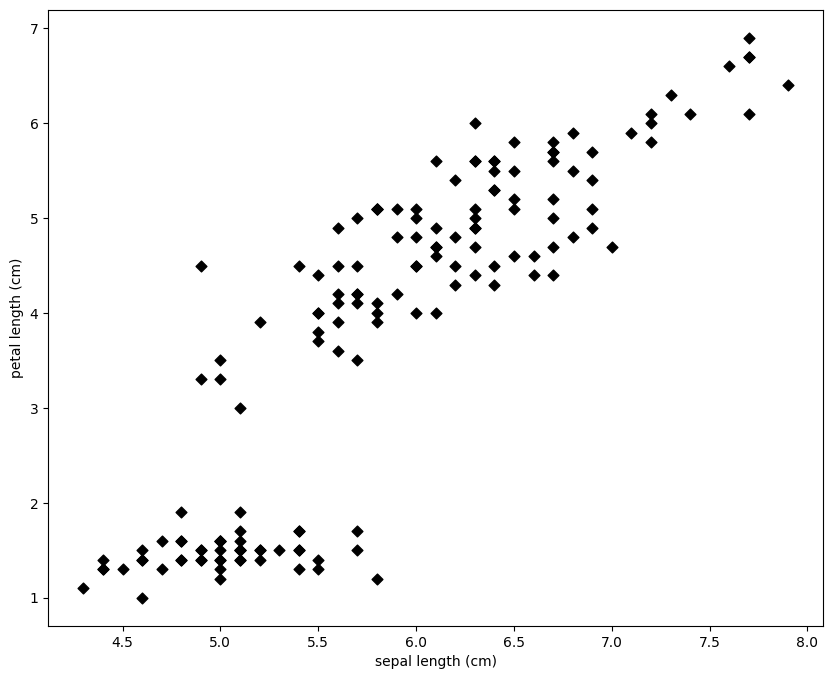

In [ ]:


#Usemos dos variables o dos caracteristicas
# let's just use two features, so that we can
# Para una mejor visualizacion
X = iris.data[:, [0, 2]]
y = iris.target
target_names = iris.target_names
feature_names = iris.feature_names
# Obtener las clases
n_class = len(set(y))

# Visualizacion de datos
plt.figure(figsize = (10,8))

#Visualizaremos todos los renglones de la columna 0 y la columna 1
plt.scatter(X[:, 0], X[:, 1], \
            color = 'k', marker = 'D', s = 30)

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[2])
plt.show()

[Ir a la explicación](#scrollTo=04b449c5)

In [ ]:
# Calcular la media de las características de cada especie para utilizarlas como centroides iniciales

initial_centroids = iris_df.groupby('target')[['sepal length (cm)', 'petal length (cm)']].mean().values

print("Centroides iniciales basados ​​en medias de especies:")
print(initial_centroids)

from sklearn.cluster import KMeans

kmean = KMeans(n_clusters=3, init=initial_centroids, n_init='auto')
kmean.fit(X)


# Utilice las medias calculadas como centroides iniciales y ejecute KMeans varias veces
# Se aumentó n_init para un cálculo de centroide más robusto

# n_clusters = numero de agrupamientos
# init = elige quienes pueden ser los centroides iniciales
# n_init = numero minimo de iteraciones para definir correctamente
   # (o la mejor opcion para ser) el centroide

Centroides iniciales basados ​​en medias de especies:
[[5.006 1.462]
 [5.936 4.26 ]
 [6.588 5.552]]


KMeans(init=array([[5.006, 1.462],
       [5.936, 4.26 ],
       [6.588, 5.552]]),
       n_clusters=3)

[Ir a la explicación](#scrollTo=04b449c5)

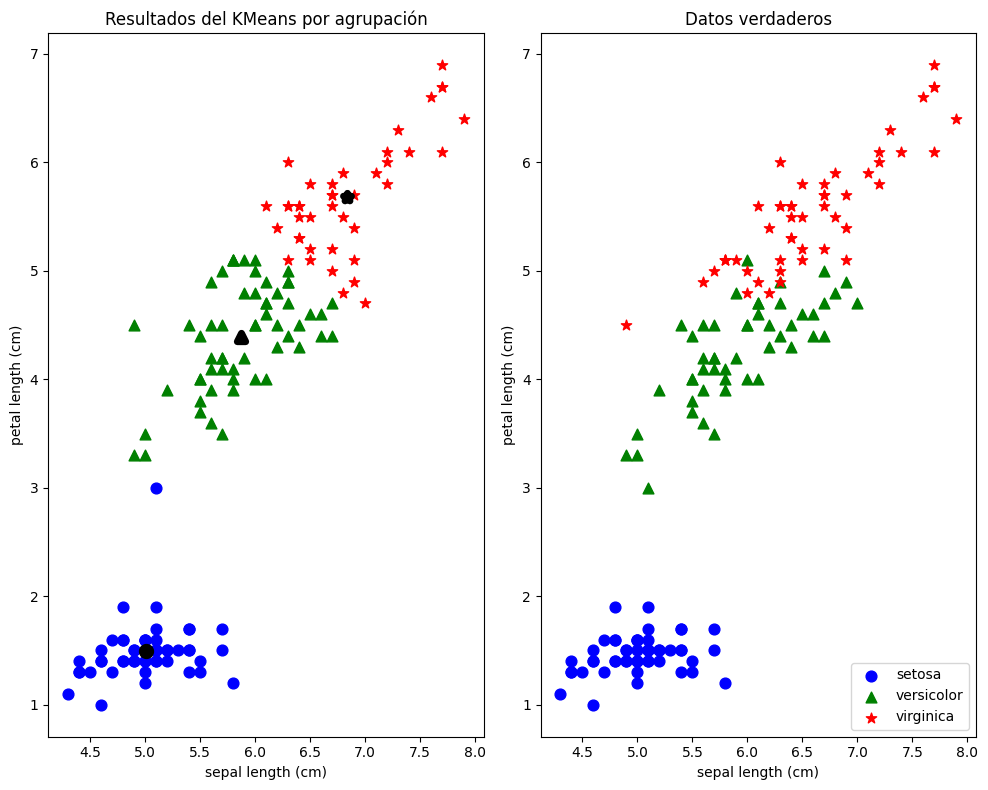

In [ ]:
# let's have a look of the data first
colors = ['b', 'g', 'r']
symbols = ['o', '^', '*']
fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
for i, c, s in (zip(range(n_class), colors, symbols)):
    ix = kmean.labels_ == i
    ax.scatter(X[:, 0][ix], X[:, 1][ix], \
                color = c, marker = s, s = 60, \
                label = target_names[i])
    loc = kmean.cluster_centers_[i]
    ax.scatter(loc[0], loc[1], color = 'k', \
               marker = s, linewidth = 5)

    ix = y == i
    ax2.scatter(X[:, 0][ix], X[:, 1][ix], \
                color = c, marker = s, s = 60, \
                label = target_names[i])

ax.set_title('Resultados del KMeans por agrupación')
ax2.set_title('Datos verdaderos')
plt.legend(loc = 4, scatterpoints = 1)
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[2])
ax2.set_xlabel(feature_names[0])
ax2.set_ylabel(feature_names[2])
plt.tight_layout()
plt.show()

In [ ]:
new_points = np.array([[5, 2],
                      [6, 5]])
kmean.predict(new_points)

array([0, 1], dtype=int32)

[Ir a la explicación](#scrollTo=04b449c5)

Results for random_state=0:
Final centroids:
[[5.87413793 4.39310345]
 [5.00784314 1.49215686]
 [6.83902439 5.67804878]]
Inertia (within-cluster sum of squares): 53.80997864410694
Standard deviation of distances to centroid for each cluster:
  Cluster 0: 0.2735
  Cluster 1: 0.2681
  Cluster 2: 0.3498
--------------------


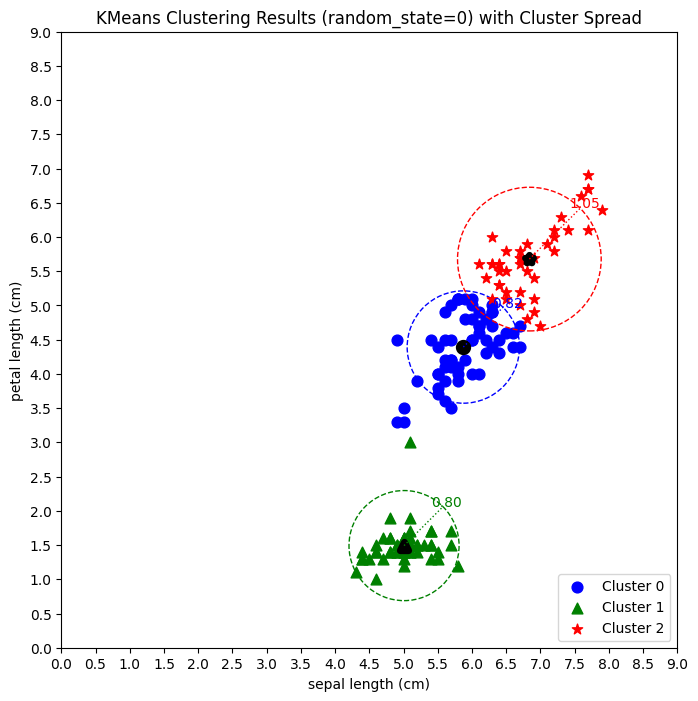

Results for random_state=1:
Final centroids:
[[5.87413793 4.39310345]
 [5.00784314 1.49215686]
 [6.83902439 5.67804878]]
Inertia (within-cluster sum of squares): 53.80997864410694
Standard deviation of distances to centroid for each cluster:
  Cluster 0: 0.2735
  Cluster 1: 0.2681
  Cluster 2: 0.3498
--------------------


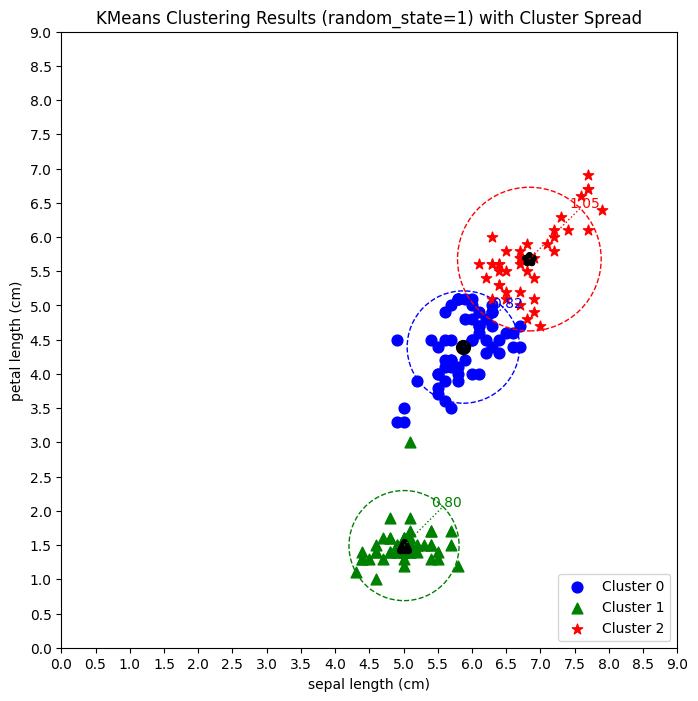

Results for random_state=2:
Final centroids:
[[5.87413793 4.39310345]
 [5.00784314 1.49215686]
 [6.83902439 5.67804878]]
Inertia (within-cluster sum of squares): 53.80997864410694
Standard deviation of distances to centroid for each cluster:
  Cluster 0: 0.2735
  Cluster 1: 0.2681
  Cluster 2: 0.3498
--------------------


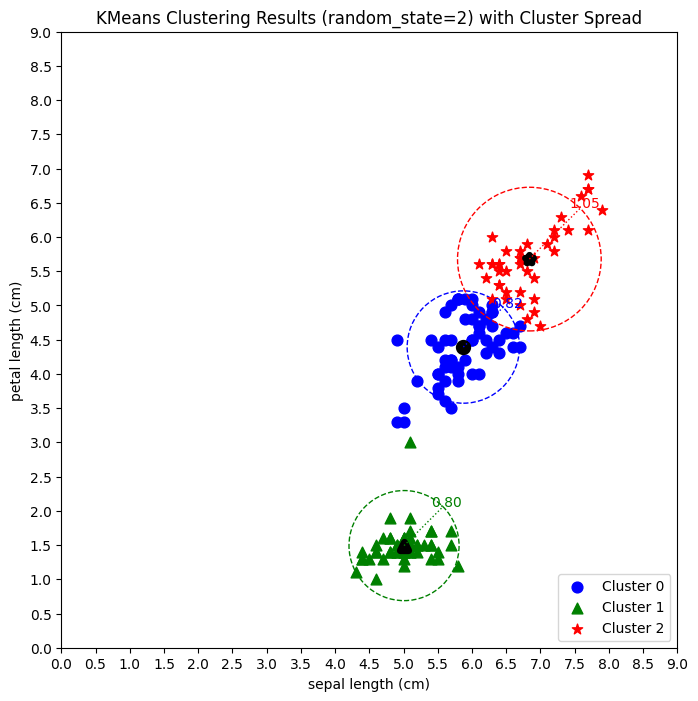

Results for random_state=3:
Final centroids:
[[5.87413793 4.39310345]
 [5.00784314 1.49215686]
 [6.83902439 5.67804878]]
Inertia (within-cluster sum of squares): 53.80997864410694
Standard deviation of distances to centroid for each cluster:
  Cluster 0: 0.2735
  Cluster 1: 0.2681
  Cluster 2: 0.3498
--------------------


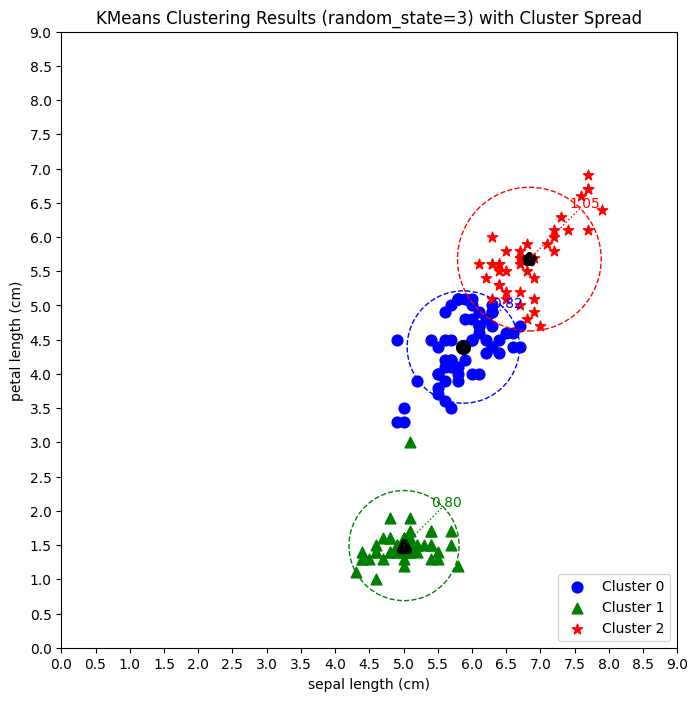

Results for random_state=4:
Final centroids:
[[6.83902439 5.67804878]
 [5.00784314 1.49215686]
 [5.87413793 4.39310345]]
Inertia (within-cluster sum of squares): 53.80997864410694
Standard deviation of distances to centroid for each cluster:
  Cluster 0: 0.3498
  Cluster 1: 0.2681
  Cluster 2: 0.2735
--------------------


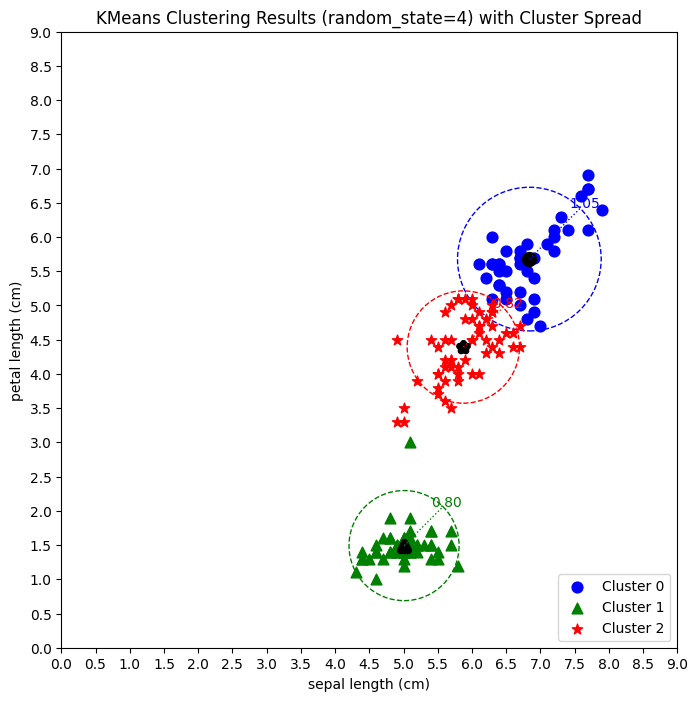

Results for random_state=5:
Final centroids:
[[5.00784314 1.49215686]
 [5.87413793 4.39310345]
 [6.83902439 5.67804878]]
Inertia (within-cluster sum of squares): 53.80997864410694
Standard deviation of distances to centroid for each cluster:
  Cluster 0: 0.2681
  Cluster 1: 0.2735
  Cluster 2: 0.3498
--------------------


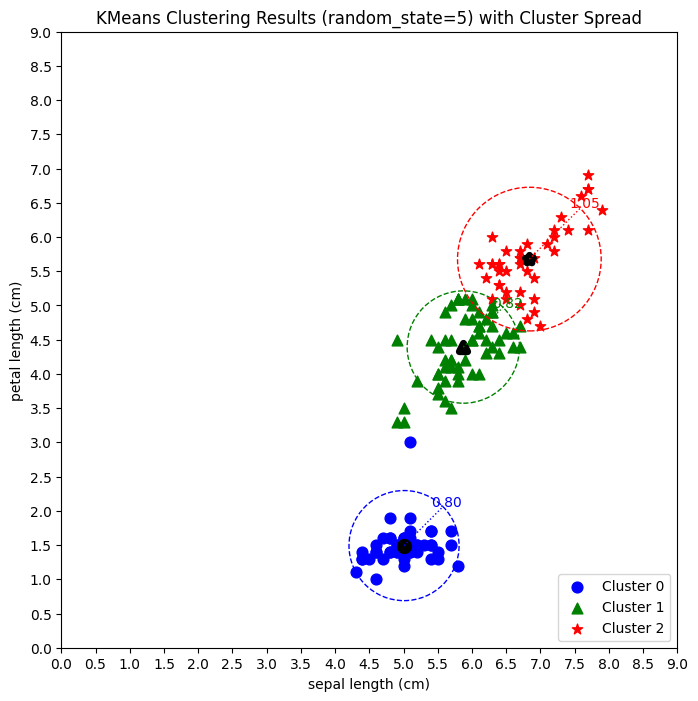

Results for random_state=6:
Final centroids:
[[6.83902439 5.67804878]
 [5.00784314 1.49215686]
 [5.87413793 4.39310345]]
Inertia (within-cluster sum of squares): 53.80997864410694
Standard deviation of distances to centroid for each cluster:
  Cluster 0: 0.3498
  Cluster 1: 0.2681
  Cluster 2: 0.2735
--------------------


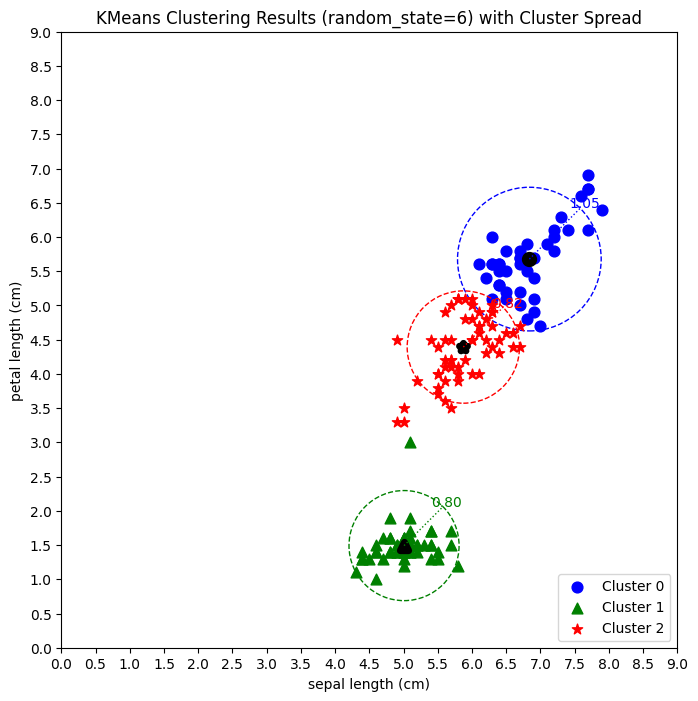

Results for random_state=7:
Final centroids:
[[5.00784314 1.49215686]
 [6.83902439 5.67804878]
 [5.87413793 4.39310345]]
Inertia (within-cluster sum of squares): 53.80997864410694
Standard deviation of distances to centroid for each cluster:
  Cluster 0: 0.2681
  Cluster 1: 0.3498
  Cluster 2: 0.2735
--------------------


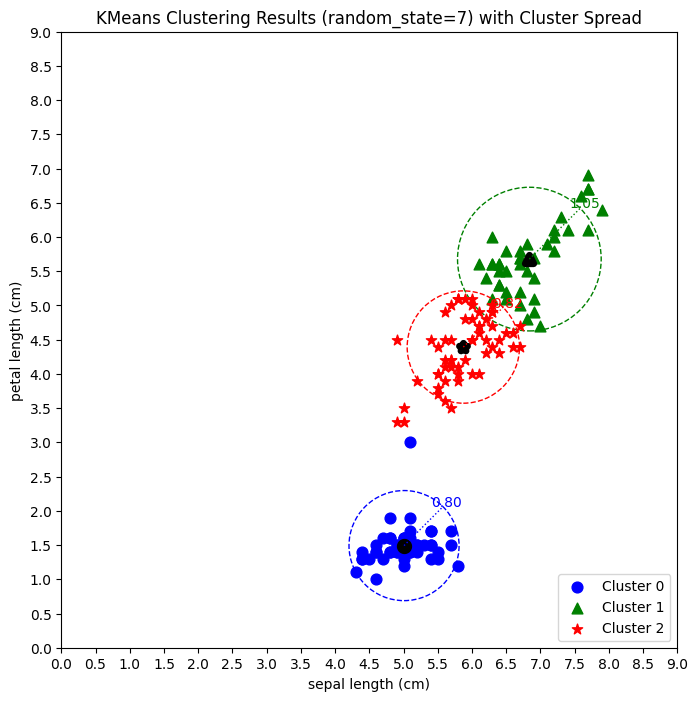

Results for random_state=8:
Final centroids:
[[6.83902439 5.67804878]
 [5.00784314 1.49215686]
 [5.87413793 4.39310345]]
Inertia (within-cluster sum of squares): 53.80997864410694
Standard deviation of distances to centroid for each cluster:
  Cluster 0: 0.3498
  Cluster 1: 0.2681
  Cluster 2: 0.2735
--------------------


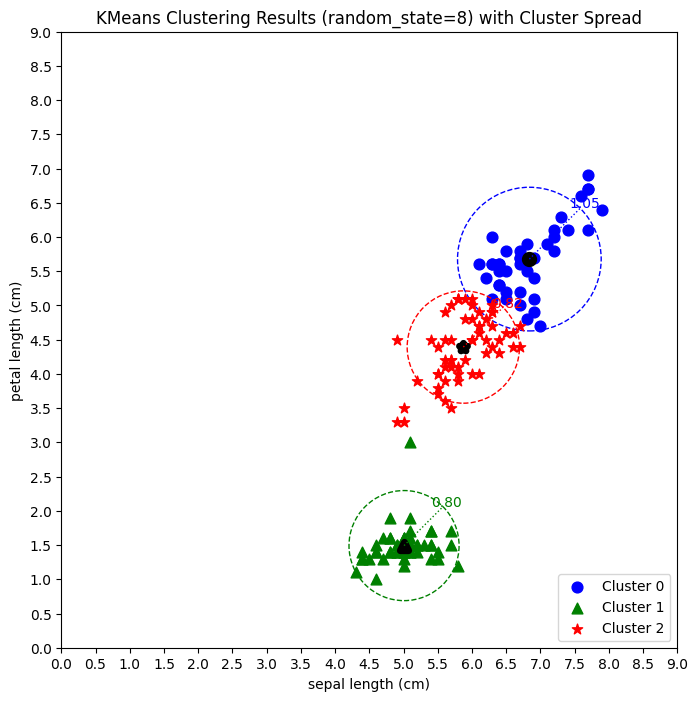

Results for random_state=9:
Final centroids:
[[5.00784314 1.49215686]
 [5.87413793 4.39310345]
 [6.83902439 5.67804878]]
Inertia (within-cluster sum of squares): 53.80997864410694
Standard deviation of distances to centroid for each cluster:
  Cluster 0: 0.2681
  Cluster 1: 0.2735
  Cluster 2: 0.3498
--------------------


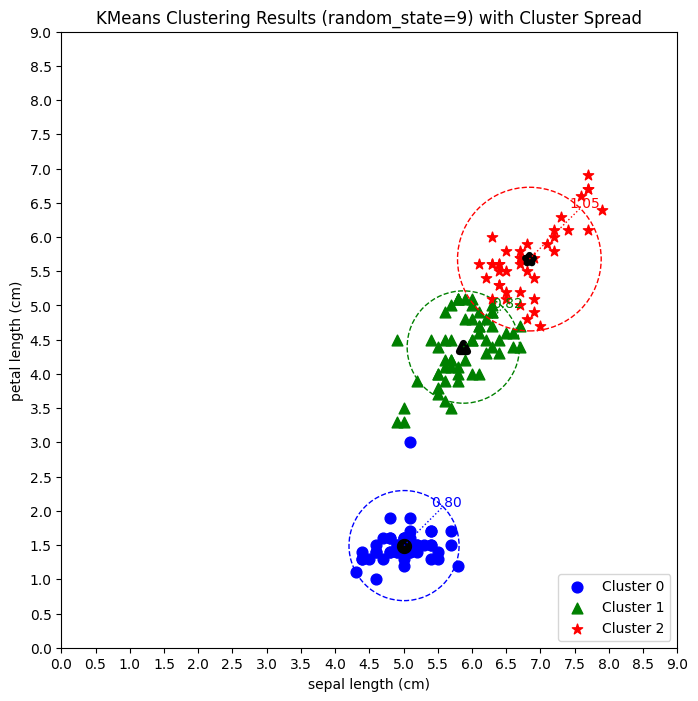

In [ ]:
# Evaluate clustering results for different random initializations and visualize them

colors = ['b', 'g', 'r']
symbols = ['o', '^', '*']

for i in range(10): # Run KMeans 5 times with different random states
    kmean_random = KMeans(n_clusters=3, n_init='auto', random_state=i)
    kmean_random.fit(X)

    print(f"Results for random_state={i}:")
    print("Final centroids:")
    print(kmean_random.cluster_centers_)
    print(f"Inertia (within-cluster sum of squares): {kmean_random.inertia_}")

    # Calculate standard deviation of distances to the centroid for each cluster
    std_devs = []
    print("Standard deviation of distances to centroid for each cluster:")
    for cluster_id in range(kmean_random.n_clusters):
        cluster_points = X[kmean_random.labels_ == cluster_id]
        centroid = kmean_random.cluster_centers_[cluster_id]
        distances = np.linalg.norm(cluster_points - centroid, axis=1)
        std_dev = np.std(distances)
        std_devs.append(std_dev)
        print(f"  Cluster {cluster_id}: {std_dev:.4f}")

    print("-" * 20)

    # Visualize the clustering results with the final centroids and circles representing spread
    fig, ax = plt.subplots(figsize=(10, 8))
    for cluster_id, c, s in zip(range(kmean_random.n_clusters), colors, symbols):
        ix = kmean_random.labels_ == cluster_id
        ax.scatter(X[:, 0][ix], X[:, 1][ix],
                   color=c, marker=s, s=60,
                   label=f'Cluster {cluster_id}')

        # Plot the centroid
        centroid = kmean_random.cluster_centers_[cluster_id]
        ax.scatter(centroid[0], centroid[1], color='k', marker=s, linewidth=5)

        # Plot a circle around the centroid with radius proportional to std dev
        # Using a larger multiplier (e.g., 3) to better cover the points
        circle_radius = std_devs[cluster_id] * 3
        circle = plt.Circle(centroid, circle_radius, color=c, fill=False, linestyle='--', alpha=1)
        ax.add_patch(circle)

        # Add a dashed line from the centroid to the edge of the circle and label it with the radius
        # We can pick an angle (e.g., 45 degrees) to draw the line for consistency
        angle_degrees = 45
        angle_radians = np.deg2rad(angle_degrees)
        end_point_x = centroid[0] + circle_radius * np.cos(angle_radians)
        end_point_y = centroid[1] + circle_radius * np.sin(angle_radians)

        ax.plot([centroid[0], end_point_x], [centroid[1], end_point_y], color=c, linestyle=':', linewidth=1)

        # Add text annotation for the radius
        # Adjust text position slightly for better visibility
        text_x = centroid[0] + circle_radius * np.cos(angle_radians) * 1.1
        text_y = centroid[1] + circle_radius * np.sin(angle_radians) * 1.1
        ax.text(text_x, text_y, f'{circle_radius:.2f}', color=c, fontsize=10, ha='center', va='center')


    ax.set_title(f'KMeans Clustering Results (random_state={i}) with Cluster Spread')
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[2])
    ax.legend(loc=4, scatterpoints=1)
    ax.set_xlim([0, 9])  # Set x-axis limits
    ax.set_ylim([0, 9])  # Set y-axis limits
    ax.set_xticks(np.arange(0, 9.5, 0.5)) # Set x-axis ticks with step 0.5
    ax.set_yticks(np.arange(0, 9.5, 0.5)) # Set y-axis ticks with step 0.5
    ax.set_aspect('equal', adjustable='box') # Set aspect ratio to equal
    plt.show()

[Ir a la explicación](#scrollTo=04b449c5)

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

In [ ]:
# Initialize KMeans with a small number of iterations to visualize initial steps
# We'll store the centroids at each iteration
centroid_history = []

# We need a custom function to track centroids during fitting
# This is a simplified approach for visualization and might not be exactly
# how scikit-learn's KMeans works internally for all parameters,
# but it serves the purpose of illustrating centroid movement.

# Let's perform KMeans manually for a few iterations to capture centroid movements
def track_kmeans_centroids(X, n_clusters, max_iter=10):
    # Initialize centroids randomly or using k-means++
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=1, max_iter=1)
    kmeans.fit(X)
    centroid_history.append(kmeans.cluster_centers_.copy())

    for i in range(max_iter - 1):
        # Assign points to the nearest centroid
        labels = kmeans.predict(X)

        # Update centroids based on the mean of assigned points
        new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(n_clusters)])

        # Check for convergence (optional, for simplicity we run for max_iter)
        # if np.allclose(new_centroids, kmeans.cluster_centers_):
        #     print(f"Converged at iteration {i+2}")
        #     break

        kmeans.cluster_centers_ = new_centroids
        centroid_history.append(kmeans.cluster_centers_.copy())

    return kmeans.labels_

# Run the tracking function
# Using a reasonable number of iterations for visualization
track_kmeans_centroids(X, n_clusters=3, max_iter=10)

print("Centroid history captured for", len(centroid_history), "iterations.")

Centroid history captured for 10 iterations.


[Ir a la explicación](#scrollTo=04b449c5)

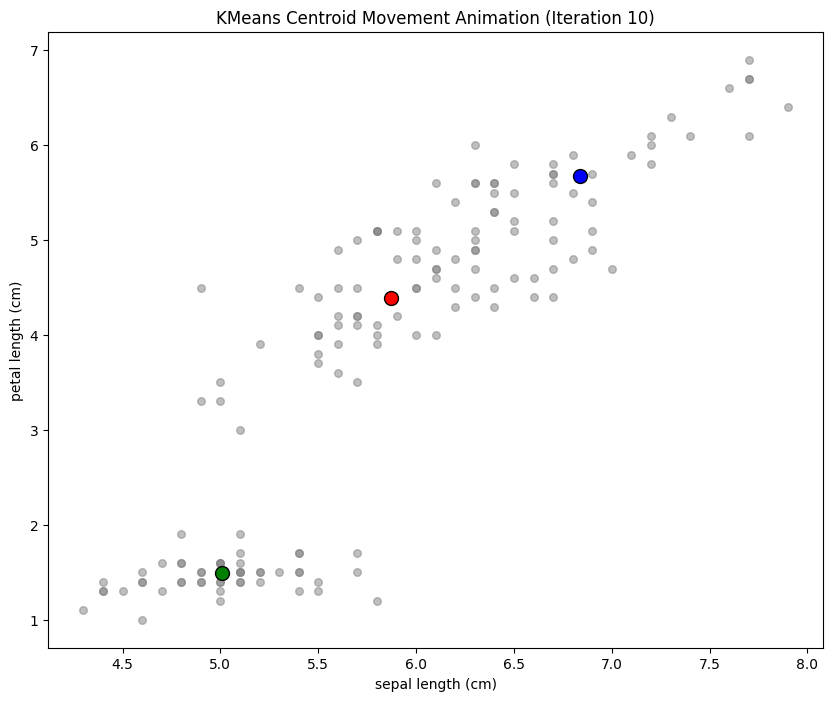

In [ ]:
# Create the animation

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X[:, 0], X[:, 1], color='gray', s=30, alpha=0.5) # Plot data points

# Initialize centroid plots
centroid_plots = [ax.plot([], [], 'o', color=colors[i], markersize=10, markeredgecolor='k')[0] for i in range(3)]

ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[2])
ax.set_title('KMeans Centroid Movement Animation')

# Function to update the plot for each frame of the animation
def update(frame):
    current_centroids = centroid_history[frame]
    for i in range(3):
        # Pass the x and y coordinates as lists
        centroid_plots[i].set_data([current_centroids[i, 0]], [current_centroids[i, 1]])
    ax.set_title(f'KMeans Centroid Movement Animation (Iteration {frame + 1})')
    return centroid_plots

# Create the animation
# The interval is in milliseconds
ani = FuncAnimation(fig, update, frames=len(centroid_history), blit=True, interval=500)

# To display the animation in Colab, you might need to save it or use specific display functions
# For a simple display in the notebook, we can try using HTML
from IPython.display import HTML
HTML(ani.to_jshtml())

[Ir a la explicación](#scrollTo=04b449c5)

# Explicación del codigo K-Means por medio de clústering.
1.  **Datos Utilizados:** Hemos aplicado K-Means a un subconjunto del conjunto de datos de Iris, cargado como `iris` y convertido a `iris_df` ([`NX_EVoljib8m`](#scrollTo=NX_EVoljib8m), [`nN2-K2TNiopA`](#scrollTo=nN2-K2TNiopA)). Para la visualización y el clustering, seleccionamos solo las características 'sepal length (cm)' y 'petal length (cm)', almacenadas en la variable `X = iris.data[:, [0, 2]]` ([`3eLZ80aIBW8W`](#scrollTo=3eLZ80aIBW8W)). Cada punto de datos $x_i$ en nuestro conjunto $X$ es un vector bidimensional. Los datos verdaderos ([`DTzQhHjqBjF4`](#scrollTo=DTzQhHjqBjF4), gráfico de la derecha) muestran tres agrupaciones distintas, correspondientes a las tres especies de Iris (`y = iris.target`).

2.  **Inicialización de Centroides ($C^{(0)}$):**
    *   En la primera ejecución ([`c70221a7`](#scrollTo=c70221a7)), los $k=3$ centroides iniciales, almacenados en `initial_centroids`, se calcularon utilizando las medias de las características seleccionadas para cada una de las tres especies de Iris verdaderas (`iris_df.groupby('target')[['sepal length (cm)', 'petal length (cm)']].mean().values`). Si $S_j^{\text{true}}$ es el conjunto de puntos que pertenecen a la especie $j$, el centroide inicial $c_j^{(0)}$ se calculó como:
        $c_j^{(0)} = \frac{1}{|S_j^{\text{true}}|} \sum_{x_i \in S_j^{\text{true}}} x_i$
        Estos `initial_centroids` se pasaron directamente al parámetro `init` de `KMeans`.
    *   En las ejecuciones con `random_state` ([`b-xudL-cYJCd`](#scrollTo=b-xudL-cYJCd)), se utilizó `init='k-means++'` y `n_init='auto'`, donde scikit-learn selecciona centroides iniciales de manera más aleatoria pero estratégica. Notamos que, a pesar de las diferentes inicializaciones, el algoritmo converge a menudo a soluciones similares (posiciones finales de los centroides en `kmean_random.cluster_centers_` y valores de inercia parecidos), aunque el orden de los clústeres puede variar.

3.  **Proceso Iterativo (Paso de Asignación y Paso de Maximización):** El algoritmo itera entre dos pasos. En el código:
    *   **Paso de Asignación:** Implementado internamente en `kmean.fit(X)` y simulado en `track_kmeans_centroids` ([`80b1302c`](#scrollTo=80b1302c)) por `labels = kmeans.predict(X)`. Cada punto de datos $x_i \in X$ se asigna al clúster cuyo centroide $c_j^{(t)}$ en la iteración $t$ es más cercano, minimizando la distancia euclidiana al cuadrado $||x_i - c_j^{(t)}||^2$. La asignación $l_i^{(t)}$ para el punto $x_i$ se almacena en el array `labels`.
    *   **Paso de Maximización:** Implementado internamente en `kmean.fit(X)` y simulado explícitamente en `track_kmeans_centroids` ([`80b1302c`](#scrollTo=80b1302c)) por `new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(n_clusters)])`. Aquí, para cada clúster $j$, se seleccionan los puntos asignados a él (`X[labels == j]`) y se calcula su media a lo largo del eje 0 (las características) usando `.mean(axis=0)`. Este promedio es el nuevo centroide $c_j^{(t+1)}$:
        $c_j^{(t+1)} = \frac{1}{|S_j^{(t)}|} \sum_{x_i \in S_j^{(t)}} x_i$
        donde $S_j^{(t)}$ es el conjunto de puntos $x_i$ para los cuales `labels[i] == j`.
    La animación en la celda [`09a79286`](#scrollTo=09a79286) (usando `centroid_history` de [`80b1302c`](#scrollTo=80b1302c)) muestra cómo los centroides se mueven en cada iteración como resultado de este paso de maximización.

4.  **Resultados del Clustering (Minimización de la Inercia):**
    *   KMeans busca minimizar la **Inercia**, calculada como la suma de las distancias cuadradas de cada punto a su centroide asignado:
        $J = \sum_{j=1}^{k} \sum_{x_i \in S_j} ||x_i - c_j||^2$
        donde $S_j$ es el conjunto final de puntos en el clúster $j$, y $c_j$ es el centroide final (`kmean.cluster_centers_[j]` o `kmean_random.cluster_centers_[j]`).
    *   La salida de la celda [`b-xudL-cYJCd`](#scrollTo=b-xudL-cYJCd) muestra la inercia final (`kmean_random.inertia_`) para cada ejecución. Una menor inercia indica una mejor agrupación.
    *   La visualización en la celda [`b-xudL-cYJCd`](#scrollTo=b-xudL-cYJCd) también muestra círculos alrededor de los centroides finales. El radio de estos círculos es proporcional a la **desviación estándar** ($\sigma_j$) de las distancias de los puntos del clúster $j$ a su centroide $c_j$. Estas distancias se calculan usando `np.linalg.norm(cluster_points - centroid, axis=1)`. La desviación estándar $\sigma_j$ se calcula con `np.std(distances)`. Los círculos (`plt.Circle`) se dibujan con un radio `circle_radius = std_devs[cluster_id] * 3`, dando una idea visual de la dispersión dentro de cada clúster.

5.  **Predicción de Nuevos Puntos:** La celda [`g1kJf9vpBnrZ`](#scrollTo=g1kJf9vpBnrZ) demuestra que, para predecir la etiqueta de clúster de un nuevo punto $x_{\text{nuevo}}$, se utiliza el método `kmean.predict(new_points)`. Internamente, esto calcula la distancia euclidiana al cuadrado $||x_{\text{nuevo}} - c_j||^2$ a cada centroide final $c_j$ y asigna el punto al clúster con el centroide más cercano, según la fórmula:
$$
l_{\text{nuevo}} = \arg\min_{j=1, \ldots, k} \|x_{\text{nuevo}} - c_j\|^2
$$

# Referencias


Las referencias para todo esto provienen de varias fuentes, incluyendo la documentación oficial de scikit-learn para KMeans, conceptos fundamentales de aprendizaje automático y análisis de datos, y ejemplos comunes de implementación de algoritmos de clustering. Aquí te dejo algunas referencias clave:

*   **Documentación de scikit-learn sobre KMeans:**
    *   [scikit-learn: KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
    *   [scikit-learn: User Guide - K-means](https://scikit-learn.org/stable/modules/clustering.html#k-means)

*   **Conceptos de Machine Learning y Clustering:**
    *   Cualquier libro o curso introductorio sobre Machine Learning cubrirá el algoritmo K-Means. Algunos recursos recomendados incluyen:
        *   "An Introduction to Statistical Learning with Applications in R" por James, Witten, Hastie, Tibshirani (conceptos fundamentales).
        *   Cursos online en plataformas como Coursera, edX, Udacity (por ejemplo, cursos de Andrew Ng en Coursera).

*   **Conjunto de Datos de Iris:**
    *   Es un conjunto de datos muy conocido y utilizado en machine learning. Puedes encontrar información sobre él en la documentación de scikit-learn o en la literatura de machine learning.
    *   [UCI Machine Learning Repository: Iris Data Set](https://archive.ics.uci.edu/ml/datasets/iris)

*   **Visualización con Matplotlib:**
    *   La documentación de Matplotlib es una excelente referencia para entender cómo crear y personalizar gráficos.
    *   [Matplotlib Documentation](https://matplotlib.org/stable/contents/index.html)

El código específico presentado en el notebook combina estos conceptos y herramientas para demostrar el funcionamiento de K-Means con el conjunto de datos de Iris.

Las referencias para todo esto provienen de varias fuentes, incluyendo la documentación oficial de scikit-learn para KMeans, conceptos fundamentales de aprendizaje automático y análisis de datos, y ejemplos comunes de implementación de algoritmos de clustering. Aquí te dejo algunas referencias clave:

* **Documentación de scikit-learn sobre KMeans:**
  * [scikit-learn: KMeans - Clase](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html): Documentación detallada de la clase `KMeans`, incluyendo parámetros, atributos y métodos.
  * [scikit-learn: Guía de Usuario - K-means](https://scikit-learn.org/stable/modules/clustering.html#k-means): Sección de la guía de usuario que explica el algoritmo K-means, sus aplicaciones y consideraciones prácticas.
* **Conceptos de Machine Learning y Clustering:**
  * **"An Introduction to Statistical Learning with Applications in R"** por James, Witten, Hastie, Tibshirani: Un libro fundamental que cubre conceptos de aprendizaje estadístico, incluyendo clustering.
  * **Cursos online:** Plataformas como Coursera, edX, Udacity ofrecen cursos introductorios y avanzados sobre Machine Learning y análisis de datos que cubren K-Means. Se recomienda buscar cursos de universidades reconocidas o instructores expertos como Andrew Ng.
* **Conjunto de Datos de Iris:**
  * **UCI Machine Learning Repository: Iris Data Set** ([https://archive.ics.uci.edu/ml/datasets/iris](https://archive.ics.uci.edu/ml/datasets/iris)): La fuente original del conjunto de datos de Iris, con descripción detallada de las características y clases.
  * **Documentación de scikit-learn sobre el conjunto de datos de Iris:** Información sobre cómo cargar y utilizar el conjunto de datos de Iris directamente desde scikit-learn.
* **Visualización con Matplotlib:**
  * **Matplotlib Documentation** ([https://matplotlib.org/stable/contents/index.html](https://matplotlib.org/stable/contents/index.html)): La documentación oficial de la biblioteca Matplotlib, esencial para crear y personalizar gráficos en Python.

El código específico presentado en el notebook combina estos conceptos y herramientas para demostrar el funcionamiento de K-Means con el conjunto de datos de Iris, enfocándose en la visualización de los centroides y la inercia.